In [1]:
%pip install scikeras

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install scikit-optimize

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from skopt import BayesSearchCV
from skopt.space import Integer, Real
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve, average_precision_score, recall_score, precision_score


from scikeras.wrappers import KerasClassifier

from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, GlobalAveragePooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

In [4]:
train = "../datasets/final_train.csv"
test = "../datasets/test.csv"

df = pd.read_csv(train)
test_df = pd.read_csv(test)

X = df.drop(columns=["label_tactic"]).values
y = df["label_tactic"].values

X_test = test_df.drop(columns=["label_tactic"]).values
y_test = test_df["label_tactic"].values

In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)
y_test_encoded = label_encoder.transform(y_test)

num_classes = len(np.unique(y_encoded))

print("Number of classes:", num_classes)

Number of classes: 4


In [6]:
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print("Train shape:", X.shape)
print("Test shape:", X_test.shape)

Train shape: (154214, 118, 1)
Test shape: (52256, 118, 1)


In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    min_delta=1e-3
)

In [8]:
def build_cnn(filters=64,kernel_size=3,dense_units=128,dropout=0.5,lr=0.001):

    
    model = Sequential([

        Conv1D(filters,kernel_size,padding="same",activation="relu",input_shape=(X.shape[1], 1)),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 2,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        Conv1D(filters * 4,kernel_size,padding="same",activation="relu"),
        BatchNormalization(),
        MaxPooling1D(2),

        GlobalAveragePooling1D(),

        Dense(dense_units, activation="relu"),

        Dropout(dropout),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
   

In [9]:
cnn_model = KerasClassifier(
    model=build_cnn,
    verbose=0,
)

In [10]:
search_spaces = {
    "model__filters": Integer(32, 128),
    "model__dense_units": Integer(64, 256),
    "model__dropout": Real(0.1, 0.5),
    "model__kernel_size": Integer(3, 7),
    "model__lr": Real(1e-5, 1e-2, prior="log-uniform"),
    "batch_size": Integer(16, 64),
    
    
}

In [11]:
bayes_search = BayesSearchCV(
    estimator=cnn_model,
    search_spaces=search_spaces,
    n_iter=5,
    cv=10,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=10,
    random_state=42
)

bayes_search.fit(X, y_encoded, callbacks=[early_stop], validation_split=0.1, epochs=20)



print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)


Fitting 10 folds for each of 1 candidates, totalling 10 fits
[CV 1/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 1/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=1.000 total time= 6.3min
[CV 2/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 2/10; 1/1] END batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037;, score=1.000 total time= 6.3min
[CV 3/10; 1/1] START batch_size=36, model__dense_units=204, model__dropout=0.47314719953913353, model__filters=62, model__kernel_size=6, model__lr=0.00017472534129202037


...

[CV 9/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.979 total time=11.3min
[CV 10/10; 1/1] START batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[CV 10/10; 1/1] END batch_size=54, model__dense_units=148, model__dropout=0.31064809485107703, model__filters=101, model__kernel_size=7, model__lr=0.0014160984697405585;, score=0.979 total time=11.3min


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Best parameters: OrderedDict({'batch_size': 55, 'model__dense_units': 97, 'model__dropout': 0.33921883100485123, 'model__filters': 109, 'model__kernel_size': 5, 'model__lr': 1.9335932336409912e-05})
Best CV score: 0.9104191581361818


In [12]:
best_params = bayes_search.best_params_

final_model = build_cnn(
    filters=best_params["model__filters"],
    kernel_size=best_params["model__kernel_size"],
    dense_units=best_params["model__dense_units"],
    dropout=best_params["model__dropout"],
    lr=best_params["model__lr"],
    
)

history = final_model.fit(
    X,
    y_encoded,
    callbacks=[early_stop],
    verbose=1,
    epochs=50
)





Epoch 1/50


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4820/4820 ━━━━━━━━━━━━━━━━━━━━ 51s 10ms/step - accuracy: 0.9093 - loss: 0.2411
Epoch 2/50
  16/4820 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.9083 - loss: 0.2359

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


4820/4820 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.9129 - loss: 0.2211
Epoch 3/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.9135 - loss: 0.2180
Epoch 4/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 50s 10ms/step - accuracy: 0.9137 - loss: 0.2171
Epoch 5/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.9138 - loss: 0.2161
Epoch 6/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 49s 10ms/step - accuracy: 0.9138 - loss: 0.2154
Epoch 7/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9139 - loss: 0.2153
Epoch 8/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 48s 10ms/step - accuracy: 0.9139 - loss: 0.2146
Epoch 9/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 45s 9ms/step - accuracy: 0.9140 - loss: 0.2141
Epoch 10/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9139 - loss: 0.2142
Epoch 11/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 43s 9ms/step - accuracy: 0.9139 - loss: 0.2141
Epoch 12/50
4820/4820 ━━━━━━━━━━━━━━━━━━━━ 46s 9ms/step - accuracy: 0.9139 - loss: 0.2139
Epoch 13/50
4820/4820 

In [13]:

train_predictions = final_model.predict(X)
test_predictions = final_model.predict(X_test)

train_predicted_classes = np.argmax(train_predictions, axis=1)
test_predicted_classes = np.argmax(test_predictions, axis=1)

4820/4820 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step
1633/1633 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step


In [14]:
from sklearn.metrics import cohen_kappa_score
predictions = final_model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

accuracy = accuracy_score(y_test_encoded, predicted_classes)
f1 = f1_score(y_test_encoded, predicted_classes, average="weighted")
kappa = cohen_kappa_score(y_test_encoded, predicted_classes)

print("\nTest Accuracy:", accuracy)
print("Test F1 Score:", f1)
print("Kappa Score:", kappa)

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

Test Accuracy: 0.9252717391304348
Test F1 Score: 0.9036764902553676
Kappa Score: 0.8801822699807645


In [15]:
print("\nClassification Report:")

print(
    classification_report(
        y_test_encoded,
        predicted_classes,
        target_names=label_encoder.classes_
    )
)

cm = confusion_matrix(y_test_encoded, predicted_classes)

print("\nFalse Positive Rate (per class)")

fpr_list = []

for i in range(len(cm)):
    FP = cm[:, i].sum() - cm[i, i]
    TN = cm.sum() - (cm[i, :].sum() + cm[:, i].sum() - cm[i, i])
    
    fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
    fpr_list.append(fpr)
    
    print(f"{label_encoder.classes_[i]}: {fpr:.4f}")

print("\nAverage FPR:", np.mean(fpr_list))


Classification Report:
                      precision    recall  f1-score   support

   Credential Access       1.00      1.00      1.00      8699
           Discovery       0.78      1.00      0.87     13431
Resource Development       0.00      0.00      0.00      2723
                none       1.00      0.96      0.98     27403

            accuracy                           0.93     52256
           macro avg       0.69      0.74      0.71     52256
        weighted avg       0.89      0.93      0.90     52256


False Positive Rate (per class)
Credential Access: 0.0000
Discovery: 0.1001
Resource Development: 0.0000
none: 0.0008

Average FPR: 0.025217280830860476


C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\metrics\_clas

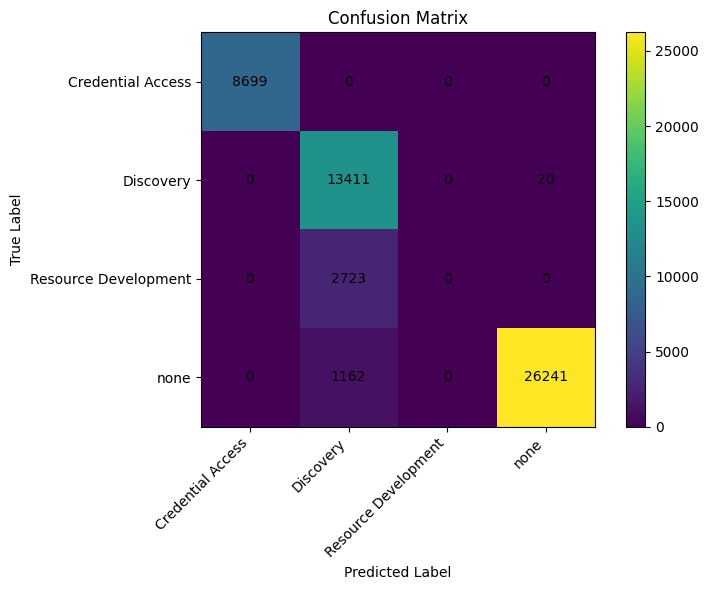

In [16]:
cm = confusion_matrix(y_test_encoded, predicted_classes)

class_names = label_encoder.classes_

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=45,
    ha="right"
)

plt.yticks(
    tick_marks,
    class_names
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

1633/1633 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step


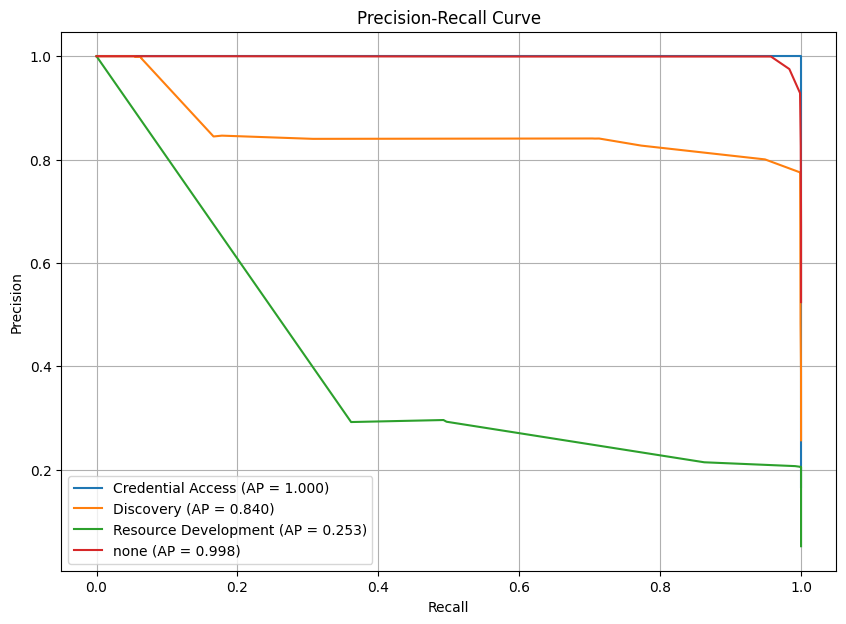

In [17]:


y_pred_proba = final_model.predict(X_test)

y_test_bin = label_binarize(
    y_test_encoded,
    classes=np.arange(num_classes)
)

plt.figure(figsize=(10, 7))

for i, class_name in enumerate(label_encoder.classes_):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    plt.plot(
        recall,
        precision,
        label=f"{class_name} (AP = {ap:.3f})"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="best")
plt.grid(True)
plt.show()

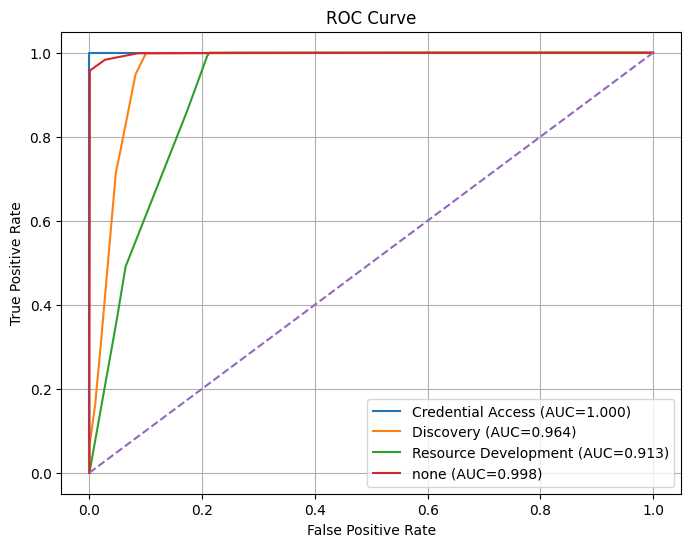

In [18]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8, 6))

for i, label in enumerate(label_encoder.classes_):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{label} (AUC={roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

metrics = []

for i, class_name in enumerate(label_encoder.classes_):

    # ROC metrics
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    roc_auc = auc(fpr, tpr)

  
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )
    ap = average_precision_score(
        y_test_bin[:, i],
        y_pred_proba[:, i]
    )

    metrics.append({
        "Class": class_name,
        "ROC AUC": round(roc_auc, 4),
        "Precision-Recall": round(ap, 4)
    })

metrics_df = pd.DataFrame(metrics)


metrics_df = metrics_df.sort_values(
    by="ROC AUC",
    ascending=False
).reset_index(drop=True)

print(metrics_df)

                  Class  ROC AUC  Precision-Recall
0     Credential Access   1.0000            1.0000
1                  none   0.9982            0.9976
2             Discovery   0.9636            0.8398
3  Resource Development   0.9134            0.2527


In [20]:
def weighted_fpr(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    fprs = []

    for i in range(len(cm)):
        FP = cm[:, i].sum() - cm[i, i]
        TN = cm.sum() - (
            cm[i, :].sum()
            + cm[:, i].sum()
            - cm[i, i]
        )

        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
        fprs.append(fpr)

    return np.mean(fprs)

In [21]:
results = {
    "Dataset": ["Training", "Test"],
    "Accuracy": [
        accuracy_score(y_encoded, train_predicted_classes),
        accuracy_score(y_test_encoded, test_predicted_classes)
    ],
    "Precision (Weighted)": [
        precision_score(y_encoded, train_predicted_classes,
                        average="weighted", zero_division=0),
        precision_score(y_test_encoded, test_predicted_classes,
                        average="weighted", zero_division=0)
    ],
    "Recall (Weighted)": [
        recall_score(y_encoded, train_predicted_classes,
                     average="weighted"),
        recall_score(y_test_encoded, test_predicted_classes,
                     average="weighted")
    ],
    "F1 (Weighted)": [
        f1_score(y_encoded, train_predicted_classes,
                 average="weighted"),
        f1_score(y_test_encoded, test_predicted_classes,
                 average="weighted")
    ],
    "FPR": [
        weighted_fpr(y_encoded, train_predicted_classes),
        weighted_fpr(y_test_encoded, test_predicted_classes)
    ]
}

results_df = pd.DataFrame(results)

print("\nCNN Performance Summary")
print(results_df.round(4).to_string(index=False))


#print("Epoch:", best_epoch)
print("\nBest parameters:", bayes_search.best_params_)
print("Best CV score:", bayes_search.best_score_)



print("\nGeneralization Gap (Train - Test)")

metrics = [
    ("Accuracy",
     accuracy_score(y_encoded, train_predicted_classes),
     accuracy_score(y_test_encoded, test_predicted_classes)),

    ("Precision",
     precision_score(y_encoded, train_predicted_classes,
                     average="weighted", zero_division=0),
     precision_score(y_test_encoded, test_predicted_classes,
                     average="weighted", zero_division=0)),

    ("Recall",
     recall_score(y_encoded, train_predicted_classes,
                  average="weighted"),
     recall_score(y_test_encoded, test_predicted_classes,
                  average="weighted")),

    ("F1",
     f1_score(y_encoded, train_predicted_classes,
              average="weighted"),
     f1_score(y_test_encoded, test_predicted_classes,
              average="weighted")),

    ("FPR",
     weighted_fpr(y_encoded, train_predicted_classes),
     weighted_fpr(y_test_encoded, test_predicted_classes))
]

for name, train_val, test_val in metrics:
    print(f"{name}: {(train_val - test_val):.4f}")


CNN Performance Summary
 Dataset  Accuracy  Precision (Weighted)  Recall (Weighted)  F1 (Weighted)    FPR
Training    0.9140                0.8601             0.9140         0.8832 0.0330
    Test    0.9253                0.8898             0.9253         0.9037 0.0252

Best parameters: OrderedDict({'batch_size': 55, 'model__dense_units': 97, 'model__dropout': 0.33921883100485123, 'model__filters': 109, 'model__kernel_size': 5, 'model__lr': 1.9335932336409912e-05})
Best CV score: 0.9104191581361818

Generalization Gap (Train - Test)
Accuracy: -0.0113
Precision: -0.0297
Recall: -0.0113
F1: -0.0205
FPR: 0.0078


In [ ]:
best_model = bayes_search.best_estimator_

y_pred = best_model.predict(X_test)

# SciKeras may return probabilities
if y_pred.ndim > 1:
    y_pred = np.argmax(y_pred, axis=1)

y_true = y_test_encoded

# --------------------------------------------------------
# Replace df_test with the ORIGINAL (unscaled) test DataFrame
# whose rows correspond exactly to X_test.
# --------------------------------------------------------
analysis_df = test_df.reset_index(drop=True).copy()

# Add labels
analysis_df["True Class"] = label_encoder.inverse_transform(y_true)
analysis_df["Predicted Class"] = label_encoder.inverse_transform(y_pred)

classes = label_encoder.classes_

for true_class in range(len(classes)):
    for pred_class in range(len(classes)):

        if true_class == pred_class:
            continue

        mask = (y_true == true_class) & (y_pred == pred_class)

        if mask.sum() == 0:
            continue

        subset = analysis_df.loc[mask].drop(
            columns=["True Class", "Predicted Class"],
            errors="ignore"
        )

        print("=" * 100)
        print(f"{classes[true_class]}  --->  {classes[pred_class]}")
        print(f"Misclassified Samples: {len(subset)}")

        common_columns = {}

        for col in subset.columns:

            if pd.api.types.is_float_dtype(subset[col]):
                continue

            values = subset[col].dropna().unique()

            if len(values) == 1:
                common_columns[col] = values[0]

        if len(common_columns):
            print("\nCommon Columns:")
            for col, value in common_columns.items():
                print(f"{col}: {value}")
        else:
            print("\nNo columns have identical values across every sample.")

        
        display(subset)

Discovery  --->  none
Misclassified Samples: 18

Common Columns:
local_resp: 0
label_tactic: Discovery
src_port_bin_1: 0
dest_port_bin_3: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_REJ: 0
conn_state_S0: 0
conn_state_SH: 0
conn_state_SHR: 0
history_Ar: 0
history_D: 0
history_F: 0
history_Hs^ADTdttTaFf: 0
history_Q: 0
history_S: 0
his

,local_resp,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
314,0,Discovery,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
3711,0,Discovery,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
6477,0,Discovery,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
7983,0,Discovery,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
10883,0,Discovery,0,1,0,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
18314,0,Discovery,0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
18344,0,Discovery,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
26220,0,Discovery,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
27875,0,Discovery,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0
29787,0,Discovery,0,0,1,1,0,0,0,1,...,0,0,1,0,0,0,0,0,0,0


Resource Development  --->  Discovery
Misclassified Samples: 2723

Common Columns:
local_resp: 0
label_tactic: Resource Development
src_port_bin_1: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
duration_bin_6.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_1.0: 1
resp_pkts_bin_2.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_REJ: 0
conn_state_RSTRH: 0
conn_state_SH: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Ar: 0
history_Arr: 0
histor

,local_resp,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
48,0,Resource Development,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
84,0,Resource Development,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
94,0,Resource Development,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
114,0,Resource Development,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
120,0,Resource Development,0,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52214,0,Resource Development,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
52224,0,Resource Development,0,0,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
52234,0,Resource Development,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
52237,0,Resource Development,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1


none  --->  Discovery
Misclassified Samples: 1162

Common Columns:
local_resp: 0
label_tactic: none
src_port_bin_1: 0
dest_port_bin_3: 0
duration_bin_2.0: 0
duration_bin_3.0: 0
duration_bin_4.0: 0
duration_bin_5.0: 0
missed_bytes_bin_1.0: 1
missed_bytes_bin_3.0: 0
orig_ip_bytes_bin_1.0: 1
orig_ip_bytes_bin_2.0: 0
orig_ip_bytes_bin_3.0: 0
orig_ip_bytes_bin_4.0: 0
orig_ip_bytes_bin_5.0: 0
orig_ip_bytes_bin_6.0: 0
orig_pkts_bin_1.0: 1
orig_pkts_bin_2.0: 0
orig_pkts_bin_3.0: 0
orig_pkts_bin_4.0: 0
orig_pkts_bin_5.0: 0
orig_pkts_bin_6.0: 0
resp_bytes_bin_3.0: 0
resp_bytes_bin_4.0: 0
resp_bytes_bin_6.0: 0
resp_ip_bytes_bin_1.0: 1
resp_ip_bytes_bin_3.0: 0
resp_ip_bytes_bin_4.0: 0
resp_ip_bytes_bin_6.0: 0
resp_pkts_bin_3.0: 0
resp_pkts_bin_4.0: 0
resp_pkts_bin_5.0: 0
resp_pkts_bin_6.0: 0
conn_state_RSTRH: 0
conn_state_SF: 0
conn_state_SHR: 0
proto_tcp: 1
proto_udp: 0
history_Ar: 0
history_Arr: 0
history_D: 0
history_Dd: 0
history_Hs^ADTdttTaFf: 0
history_Q: 0
history_SAhDTaFf: 0
history_SAhDTd

,local_resp,label_tactic,src_port_bin_1,src_port_bin_2,src_port_bin_3,dest_port_bin_1,dest_port_bin_2,dest_port_bin_3,duration_bin_0.0,duration_bin_1.0,...,history_^r,service_dce_rpc,service_dns,service_ftp,service_gssapi,service_http,service_krb_tcp,service_ntp,service_ssl,service_unknown
69,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
92,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
242,0,none,0,0,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
289,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
320,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52078,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
52143,0,none,0,1,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,1
52229,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
52242,0,none,0,1,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
